In [92]:
# # %pip install --upgrade pip
# %pip install gmsh
# %pip install meshio --user

In [93]:
import gmsh
import numpy as np
import scipy.optimize
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib


In [94]:
show_gmsh_window = False
msh_file_name = "shell_mesh_net.msh"

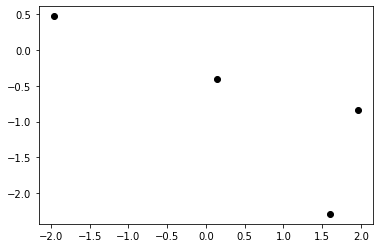

In [95]:
# Chamber radius
a = .2
chamber_spacing_scale = 5.0
N_chambers = 4

# Outer domain boundary radius
b = 5

# Mesh dx
dx = 0.2

# Generate random centers
np.random.seed(6)
xy = chamber_spacing_scale * (np.random.rand(N_chambers, 2,) - 0.5)
plt.plot(xy[:,0], xy[:,1], 'ok')

In [96]:
gmsh.initialize()

bdry_points = [
  # Bounding box vertices
  gmsh.model.geo.addPoint(-0.5, -0.5, 0, dx),
  gmsh.model.geo.addPoint(0.5,  -0.5, 0, dx),
  gmsh.model.geo.addPoint(0.5,  0.5,  0, dx),
  gmsh.model.geo.addPoint(-0.5, 0.5,  0, dx),
  # Outer circle points
  gmsh.model.geo.addPoint(0.0, 0.0, 0, dx),
  gmsh.model.geo.addPoint(b, 0.0, 0, dx),
  gmsh.model.geo.addPoint(-b, 0.0, 0, dx), 
]

chamber_points = []
for i in range(xy.shape[0]):
  chamber_points.extend((
    gmsh.model.geo.addPoint(xy[i,0], xy[i,1], 0, dx),
    gmsh.model.geo.addPoint(xy[i,0] + a, xy[i,1], 0, dx),
    gmsh.model.geo.addPoint(xy[i,0] - a, xy[i,1], 0, dx),
  ))

lines = [
  # Box lines
  # gmsh.model.geo.add_line(points[0], points[1]),
  # gmsh.model.geo.add_line(points[1], points[2]),
  # gmsh.model.geo.add_line(points[2], points[3]),
  # gmsh.model.geo.add_line(points[3], points[0]),
]

arcs_outer = [
  # Cirle arcs for outer circle
  gmsh.model.geo.addCircleArc(bdry_points[5], bdry_points[4], bdry_points[6]),
  gmsh.model.geo.addCircleArc(bdry_points[6], bdry_points[4], bdry_points[5]),
]

arcs_chambers = []
for i in range(xy.shape[0]):
  arcs_chambers.extend((
    gmsh.model.geo.addCircleArc(chamber_points[3*i+1], chamber_points[3*i], chamber_points[3*i+2]),
    gmsh.model.geo.addCircleArc(chamber_points[3*i+2], chamber_points[3*i], chamber_points[3*i+1]),
  ))

loops = [
  # Bounding box loop
  # gmsh.model.geo.add_curve_loop(lines),
  # Outer circle loop
  gmsh.model.geo.add_curve_loop(arcs_outer),
]
# Magma chamber boundary loops
for i in range(xy.shape[0]):
  loops.append(gmsh.model.geo.add_curve_loop(arcs_chambers[2*i:2*i+2]))

surfaces = [
  # Bounding box and inner circle
  # gmsh.model.geo.add_plane_surface([loops[0], loops[1]]),
  # Outer circle and inner circle
  gmsh.model.geo.add_plane_surface([loops[0], *loops[1:]]),
]

# Physical groups
surfaces_physical = [gmsh.model.addPhysicalGroup(2, surfaces, name="surface")]
# lines_physical = [gmsh.model.addPhysicalGroup(1, lines, name=f"box")]
outer_arcs_physical = [gmsh.model.addPhysicalGroup(1, arcs_outer, name=f"circle_out")]
inner_arcs_physical = [gmsh.model.addPhysicalGroup(1, arcs_chambers, name=f"circle_in")]

for i in range(N_chambers):
  chambers_physical = [gmsh.model.addPhysicalGroup(1, arcs_chambers[2*i:2*i+2], name=f"chamber_{i}")]

gmsh.model.geo.synchronize()
gmsh.model.mesh.generate()
gmsh.write(msh_file_name)

In [97]:
if show_gmsh_window:
  import sys
  if 'close' not in sys.argv:
      gmsh.fltk.run()

gmsh.finalize()

In [98]:
''' Read mesh and process '''
import meshio
# mesh = meshio.read("test_mesh.msh")
mesh = meshio.read(msh_file_name)
mesh

<meshio mesh object>
  Number of points: 3032
  Number of cells:
    line: 79
    line: 79
    line: 4
    line: 4
    line: 4
    line: 4
    line: 4
    line: 4
    line: 4
    line: 4
    triangle: 5880
  Cell sets: circle_out, circle_in, chamber_0, chamber_1, chamber_2, chamber_3, surface, gmsh:bounding_entities
  Point data: gmsh:dim_tags
  Cell data: gmsh:physical, gmsh:geometrical
  Field data: circle_out, circle_in, chamber_0, chamber_1, chamber_2, chamber_3, surface

In [99]:
n_nodes = mesh.points.shape[0]
n_cells = np.concatenate(mesh.cell_sets["surface"]).size
n_nodes, n_cells

(3032, 5880)

In [100]:
def read_points(mesh, tag:str, reverse=False):
  # Read list of arrays containing edges [node_idx_i, node_idx_j] for lines or
  # cell (hyperedge) [node_idx_i, node_idx_j, node_idx_k] for tris
  edges = [mesh.cells[i].data[idx_set] for i, idx_set in enumerate(mesh.cell_sets[tag])]
  # Flatten collection of edges into array with shape (ne, 2) belonging to boundary
  edges_flat = np.concatenate([part for part in edges if part.size > 0])
  if reverse:
    edges_flat = np.flip(edges_flat, axis=1)
  # Compute list of coordinates belonging to each edge (n_edges, 2 (vertices on edge), 3 (dimension))
  points = mesh.points[edges_flat]

  # Plot the identified points and print shape
  plt.scatter(points[...,0].ravel(), points[...,1].ravel())
  print(f"Points array shape: {points.shape}")
  return points, edges_flat

Points array shape: (5880, 3, 3)


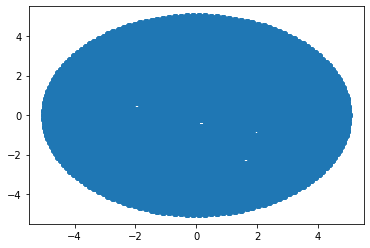

In [101]:
tri_points, tri_indices = read_points(mesh, "surface", reverse=False)

Points array shape: (32, 2, 3)
Points array shape: (158, 2, 3)


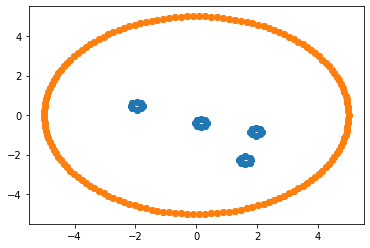

In [102]:
circ_in_points, circ_in_indices = read_points(mesh, "circle_in", reverse=False)
circ_out_points, circ_out_indices = read_points(mesh, "circle_out", reverse=True)

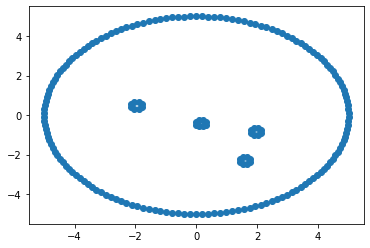

In [103]:
# Centroids by cell (ncells)
tri_centroids = tri_points.mean(axis=1, keepdims=False)

# Merge arrays of boundary cell-centers
n_circ_in_elts = circ_in_points.shape[0]
n_circ_out_elts = circ_out_points.shape[0]
bdry_points = np.concatenate([circ_in_points, circ_out_points], axis=0)
bdry_edge_centers = bdry_points.mean(axis=1, keepdims=False)
plt.scatter(bdry_edge_centers[:,0], bdry_edge_centers[:,1])


Points array shape: (8, 2, 3)
Points array shape: (8, 2, 3)
Points array shape: (8, 2, 3)
Points array shape: (8, 2, 3)


[array([0, 1, 2, 3, 4, 5, 6, 7]),
 array([ 8,  9, 10, 11, 12, 13, 14, 15]),
 array([16, 17, 18, 19, 20, 21, 22, 23]),
 array([24, 25, 26, 27, 28, 29, 30, 31])]

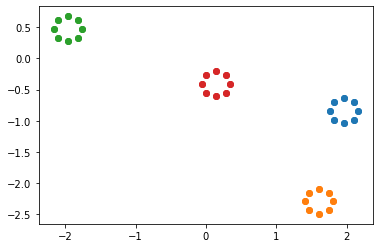

In [104]:
''' Partition boundary edge indices into each chamber'''

# Build map from pair of node indices to index
edge_to_index = {tuple(v): i for i, v in enumerate(circ_in_indices)}

chamber_global_indices = [None for i in range(N_chambers)]
for i in range(N_chambers):
  # Get boundary edges as pairs of node indices
  _, bdry_edge_indices = read_points(mesh, f"chamber_{i}", reverse=False)
  # Map pairs to indices for boundary edge degrees of freedom
  chamber_global_indices[i] = np.array([edge_to_index[tuple(edge)]
                                        for edge in bdry_edge_indices])
chamber_global_indices

In [105]:
''' Compute boundary membership of cells '''
# IDs of nodes that lie on the circular boundary
node_id_circ_in = np.unique(circ_in_indices.ravel())
node_id_circ_out = np.unique(circ_out_indices.ravel())

# Compute boolean array showing which cell ID is on the boundaries
is_cell_on_bdry_circ_in = np.empty((tri_indices.shape[0]), dtype=bool)
is_cell_on_bdry_circ_out = np.empty((tri_indices.shape[0]), dtype=bool)
for i in range(tri_indices.shape[0]):
  # Check membership of any bdry node along axis 1
  if len(np.intersect1d(tri_indices[i,:], node_id_circ_in)) == 0:
    is_cell_on_bdry_circ_in[i] = False
  else:
    is_cell_on_bdry_circ_in[i] = True
  # Check membership of any bdry node along axis 1
  if len(np.intersect1d(tri_indices[i,:], node_id_circ_out)) == 0:
    is_cell_on_bdry_circ_out[i] = False
  else:
    is_cell_on_bdry_circ_out[i] = True

In [106]:
''' Compute tri-element areas '''
tri_areas = 0.5 * np.abs(np.cross(tri_points[:,2,:] - tri_points[:,0,:],
         tri_points[:,1,:] - tri_points[:,0,:])[:,-1])
tri_areas.sum(), np.pi*(1.5**2 - 0.25**2)

(78.06656897646873, 6.872233929727672)

Laplace fundamental solution

In [107]:
def G(r):
  ''' Laplace fundamental solution '''
  return -1 / (4.0 * np.pi) * np.log(np.einsum("...i, ...i -> ...", r, r))

def G_vec(r):
  ''' Vectorized Laplace fundamental solution '''
  r2 = np.einsum("...i, ...i -> ...", r, r)
  np.log(r2, out=r2, where=r2>0)
  return r2 / (-4.0 * np.pi)

def dGdn(r, nhat):
  ''' d/dn of Laplace fundamental solution '''
  rnorm = np.linalg.norm(r,axis=-1)
  drdn = np.einsum("...i, ...i -> ...", -nhat, r/rnorm)
  return -1 / (2.0 * np.pi * rnorm) * drdn

def dGdn_vec(r, nhat):
  ''' Vectorized d/dn of Laplace fundamental solution '''
  r2 = np.einsum("...i, ...i -> ...", r, r)
  np.divide(np.einsum("...i, ...i -> ...", -nhat, r),
            -2.0 * np.pi * r2, out=r2, where=r2>0)
  return r2

def rotate_vec(v):
  ''' Rotate vector counterclockwise 90 degrees along last axis '''
  w = v.copy()
  w[...,[1,0]] = w[...,[0,1]]
  w[...,0] *= -1
  return w

Area-integration of Laplace fundamental solution

In [108]:
def int_r_G(R):
  ''' r * G partially integrated in r from 0 to r = R '''
  return (-1 / (2.0 * np.pi)) * R * R * (2 * np.log(R) - 1.0) / 4.0

def integrateG_ws(x_vertices, N_per_side=3, debug=False, method=2):
  ''' Integrates G in triangle including weak singularity.
  Polar coordinate integration dr dtheta. Analytic integration in
  dr direction, numerical integration in theta(r).
  
  Due to curvature approximation of the dtheta element, max expected order is 2.
  '''
  theta_tot = 0
  I = 0
  # Compute vertex coordinates relative to centroid
  x_shift = x_vertices - x_vertices.mean(axis=0)
  for _ii in range(3):
    # Compute vector representing edge of triangle
    _dx = x_shift[_ii] - x_shift[_ii-1]
    for _jj in range(N_per_side):
      # Trap integration along this edge
      interval_start  = x_shift[_ii-1] + (_jj) * _dx / N_per_side
      interval_center = x_shift[_ii-1] + (_jj + 0.5) * _dx / N_per_side
      interval_end    = x_shift[_ii-1] + (_jj + 1) * _dx / N_per_side
      r_start  = np.linalg.norm(interval_start)
      r_center = np.linalg.norm(interval_center)
      r_end    = np.linalg.norm(interval_end)
      theta_start = np.arctan2(interval_start[1], interval_start[0])
      theta_end   = np.arctan2(interval_end[1], interval_end[0])
      dtheta = np.mod(theta_end - theta_start, 2*np.pi)
      if method==3:
        dI = (int_r_G(r_start) + 4 * int_r_G(r_center) + int_r_G(r_end)) * dtheta / 6.0
      elif method==2:
        dI = (0.5 * int_r_G(r_start) + 0.5 * int_r_G(r_end)) * dtheta
      else:
        raise ValueError("Input param `method` options: {2, 3}.")
      I += dI
      if debug:
        print(dtheta, dI)
        theta_tot += dtheta
        plt.plot(interval_center[0], interval_center[1], '.')

  if debug:
    plt.plot(0, 0, 'ko')
    print(f"Total angle: {theta_tot/np.pi} * pi")
  return I

In [109]:
# Node counting
n_cells = tri_centroids.shape[0]
n_bdry_node = bdry_edge_centers.shape[0]
N = n_cells + n_bdry_node

# Assemble global x points as list (bdry_centers, tri_centers)
x_nodes = np.concatenate((bdry_edge_centers[:,0:2],
                          tri_centroids[:,0:2],), axis=0)

def assemble(plot_normal_vecs=False, N_per_side=10):
  K = np.zeros((N, n_bdry_node)) # Single-layer potential coefficient matrix (K @ du/dn)
  C = np.zeros((N, n_bdry_node)) # Double-layer potential coefficient matrix (dK/dn @ u)
  M = np.zeros((N, n_cells))     # Volume integral (dK/dt @ u)
  
  ''' Compute boundary contributions

  Compute regular parts of operators K, C that multiply dudn and u respectively.
  Then compute singular part of K using explicit integration. Singular part
  of C is zero since dr/dn is zero on the boundary.

  To access the jth boundary element, use bdry_points[j,:,0:2] for the vertices
  and bdry_edge_centers[j,0:2] for the boundary center.
  '''
  # Matrix of all r-vectors with shape (n_bdry_nodes + n_cells, n_bdry_nodes, 2)
  r_all = (x_nodes[:,np.newaxis,:] - bdry_edge_centers[np.newaxis,:,0:2])
  # Directed boundary element dg (dgamma) with shape (n_bdry_node, 2,)
  dg = (bdry_points[:,1,0:2] - bdry_points[:,0,0:2])
  # Measure of each boundary element with shape (n_bdry_node,) 
  dg_size_all = np.linalg.norm(dg, axis=-1)
  # Compute outward normal unit vectors with shape (n_bdry_node, 2,)
  dn_all = rotate_vec(dg)
  dn_all /= np.linalg.norm(dn_all, axis=-1)[:,np.newaxis]

  # Vectorized computation of K = G(r) * dgamma_j, operator for @ dudn
  K = G_vec(r_all) * dg_size_all
  # Vectorized computation of C = dG/dn(r) * dgamma_j, operator for @ u
  C = dGdn_vec(r_all, dn_all) * dg_size_all
  # Compute singular boundary integrals using exact integration around pole
  for i in range(n_bdry_node):
    r_eff = (dg_size_all[i]/2)
    K[i,i] = 2 * (-1 / (2.0 * np.pi)) * (r_eff * np.log(r_eff) - r_eff)

  # Option to plot normal vectors
  if plot_normal_vecs:
    for j in range(n_bdry_node):
      plt.arrow(bdry_edge_centers[j,0], bdry_edge_centers[j,1],
                dn_all[j,0], dn_all[j,1], head_width=0.06)

  ''' Compute volume contributions

  Compute regular parts of operator M multiplies u_interior.
  Then compute singular part of M using explicit integration in r, numerically
  integrating in angle theta. 

  To access the jth cell, use x_vertices[j,:,0:2] for the vertices
  and tri_centroids[j,0:2] for the boundary center.
  '''

  # Matrix of all r-vectors with shape (n_bdry_nodes + n_cells, n_cells, 2)
  r_all = (x_nodes[:,np.newaxis,:] - tri_centroids[np.newaxis,:,0:2])
  # Vectorized computation of M = G(r) * dOmega_j, operator for @ u_interior
  M = G_vec(r_all) * tri_areas

  # Shift vertex coordinates relative to centroid (n_cells, 3, 2,)
  x_shift = (tri_points[:,:,0:2] - tri_points[:,:,0:2].mean(axis=1, keepdims=True))
  # Compute vectors representing triangle edges
  _dx = x_shift[:,[1,2,0],:] - x_shift
  # Set vector of variables in [0, 1] parametrizing distance along edge
  xi = np.expand_dims(
    np.linspace(0, 1, N_per_side, endpoint=False) / N_per_side, axis=(1,2,3))
  # Compute interval start points with shape (N_per_side, n_cells, 3, 2)
  interval_start = x_shift + xi * _dx
  # Compute interval end points with shape (N_per_side, n_cells, 3, 2)
  interval_end = x_shift + (xi + 1/N_per_side) * _dx
  # Convert interval endpoints to (r, theta)
  r_start = np.linalg.norm(interval_start, axis=-1)
  r_end = np.linalg.norm(interval_end, axis=-1)
  theta_start = np.arctan2(interval_start[...,1], interval_start[...,0])
  theta_end = np.arctan2(interval_end[...,1], interval_end[...,0])
  # Compute dtheta, wrapping to [0, 2*pi]
  dtheta = np.mod(theta_end - theta_start, 2*np.pi)
  # Compute second-order quadrature of weakly singular part as vector of
  # size (n_cells,) into bottom part of M (tall matrix; bottom part will become
  # block diagonal of larger square matrix)
  M[np.arange(0,n_cells) + n_bdry_node, np.arange(0,n_cells)] = np.einsum(
    "i...k, i...k -> ...",
    0.5 * int_r_G(r_start) + 0.5 * int_r_G(r_end), dtheta)

  return K, C, M

In [110]:
K, C, M = assemble()

In [111]:
gt_gradient = 0.1
def geotherm(z):
  return -gt_gradient * z

LHS matrix and mappings from previous timestep are dense


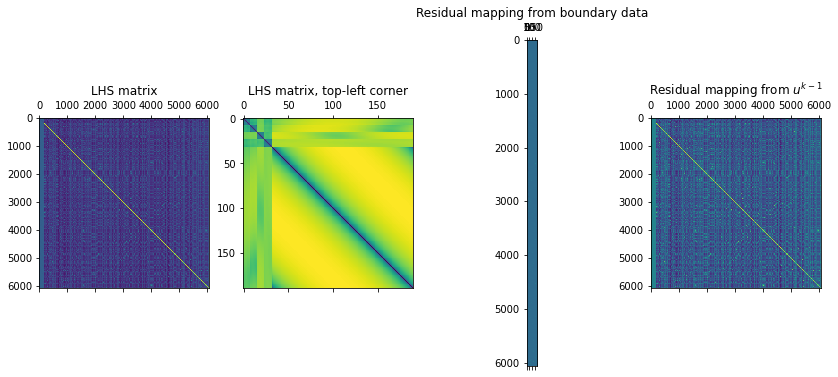

In [112]:
''' Matrix build '''

# Numerical method parameters
dt = 1e-2
theta = 1.0
# Geometric coefficient from deriving the boundary representation
beta_d = 1.0
beta_b = 0.5

L = np.concatenate((-K, M/dt), axis=1)
L[n_bdry_node:,n_bdry_node:] += beta_d * theta * np.eye(n_cells)

# Full-sized operators
C_op = -C.copy()
C_op[:n_bdry_node,:] -= beta_b * np.eye(n_bdry_node)
D_op = (M/dt).copy()
D_op[n_bdry_node:,:] += beta_d * (theta - 1.0) * np.eye(n_cells)
D_op = np.concatenate((np.zeros((N, n_bdry_node)), D_op), axis=1)

fig, ax = plt.subplots(1, 4, figsize=(14,6))
ax[0].matshow(L)
ax[0].set_title("LHS matrix")
ax[1].matshow(L[0:n_bdry_node, 0:n_bdry_node])
ax[1].set_title("LHS matrix, top-left corner")
ax[2].matshow(C_op)
ax[2].set_title("Residual mapping from boundary data")
ax[3].matshow(D_op)
ax[3].set_title("Residual mapping from $u^{k-1}$")

print("LHS matrix and mappings from previous timestep are dense")

In [113]:
# Matrix of all r-vectors with shape (n_bdry_nodes + n_cells, n_bdry_nodes, 2)
r_all = (x_nodes[:,np.newaxis,:] - bdry_edge_centers[np.newaxis,:,0:2])
# Directed boundary element dg (dgamma) with shape (n_bdry_node, 2,)
dg = (bdry_points[:,1,0:2] - bdry_points[:,0,0:2])
# Measure of each boundary element with shape (n_bdry_node,) 
dg_size_all = np.linalg.norm(dg, axis=-1)
# Compute outward normal unit vectors with shape (n_bdry_node, 2,)
dn_all = rotate_vec(dg)
dn_all /= np.linalg.norm(dn_all, axis=-1)[:,np.newaxis]

In [114]:
# Set boundary conditions
u_bdry = np.zeros((n_bdry_node,1))
# Set Dirichlet data on the inner boundary (access using concatenation order)
u_bdry[0:node_id_circ_in.size] = 1.0
# Set Dirichlet d ata on the outer boundary
circ_out_slice = slice(n_circ_in_elts, n_circ_in_elts+n_circ_out_elts)
u_bdry[circ_out_slice] = geotherm(x_nodes[circ_out_slice, 1:2])

# Set initial conditions
r_eval = np.linalg.norm(tri_centroids, axis=1)
# Evaluate data in cell
IC_cell_data = geotherm(x_nodes[n_bdry_node:, 1])
# Evaluate Neumann data on inner boundary (approx)
IC_bdry_circ_in_neumann = 1.0/dx
# Evaluate Neumann data on boundary (geothermal gradient)
IC_bdry_circ_out_neumann = (-gt_gradient * dn_all[n_circ_in_elts:, 1])

# Fill data into mixed vector
u0 = np.zeros((N, )) 
u0[0:n_circ_in_elts] = IC_bdry_circ_in_neumann
u0[n_circ_in_elts:n_circ_in_elts+n_circ_out_elts] = IC_bdry_circ_out_neumann
u0[n_bdry_node:] = IC_cell_data
u0 = u0[:,np.newaxis]

In [115]:
lu, piv = scipy.linalg.lu_factor(L)

In [138]:
''' Timestepping '''

u = u0.copy()

# Timestepping
N_t = 100

# v_hist = np.zeros((N_t, n_circ_elts,))
u_hist = np.zeros((N_t, *u0.shape,))
t_hist = dt * np.arange(1,N_t+1)

for i in range(N_t):
  # Solve equation
  #   L @ q^{k} == CG @ u_Gamma + DG @ q^{k-1}
  # u = np.linalg.solve(L, C_op @ u_bdry + D_op @ u)
  u = scipy.linalg.lu_solve((lu, piv), C_op @ u_bdry + D_op @ u)
  # v_hist[i,:] = u[:n_circ_elts].ravel()
  u_hist[i,...] = u
# plt.plot(u)

In [137]:
t_hist[-1]

0.99

1.3116238494673038

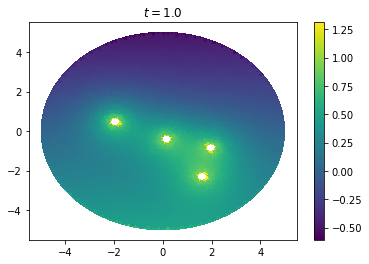

In [ ]:
# Extract u_interior (u_Omega)
u_int = u[n_bdry_node:]
# Generate color plot
triangulation = matplotlib.tri.Triangulation(mesh.points[:,0], mesh.points[:,1], tri_indices)
plt.tripcolor(triangulation, u_int.squeeze())
plt.colorbar()
plt.title(f"$t = {t_hist[-1]}$")
u_int.max()

Text(0.5, 1.0, '$t = 1.0$')

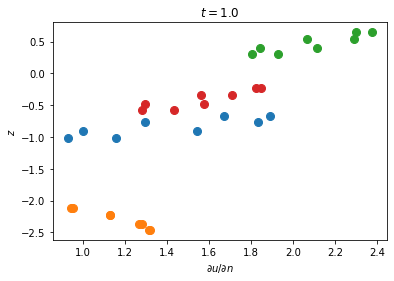

In [141]:
''' Plot temperature gradient at each chamber boundary '''
v = u[:n_bdry_node]
v_chambers = v[:n_circ_in_elts]
v_outer = v[n_circ_in_elts:]

# Extract depth of points on chamber boundary
depth_chamber_points = bdry_edge_centers[:n_circ_in_elts,1]
for i in range(N_chambers):
  plt.plot(v_chambers[chamber_global_indices[i]], depth_chamber_points[chamber_global_indices[i]], '.', markersize=16)
plt.xlabel("$\partial u/\partial n$")
plt.ylabel("$z$")
plt.title(f"$t = {t_hist[-1]}$")

Text(0.5, 1.0, 'Temperature along line x = 0')

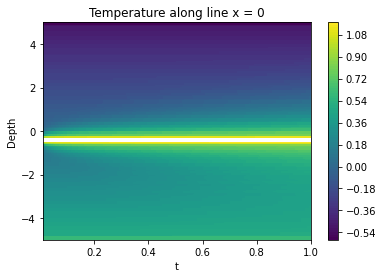

In [164]:
''' Plot along the center line x = 0 '''
trifinder = triangulation.get_trifinder()

probe_line = np.linspace(-b, b, 1000)
pick_indices = np.array([int(trifinder(0.0, y)) for y in probe_line])

u_int_hist = u_hist[:,n_bdry_node:,0]
u_hist_along_line = np.where(pick_indices >= 0, u_int_hist[:,pick_indices], np.nan)

# plt.plot(u_hist_along_line[6,:])
plt.contourf(t_hist, probe_line, u_hist_along_line.T, levels=100)
plt.colorbar()
plt.ylabel("Depth")
plt.xlabel("t")
plt.title("Temperature along line x = 0")

Text(0, 0.5, '$\\partial u/\\partial r$, mean all chambers')

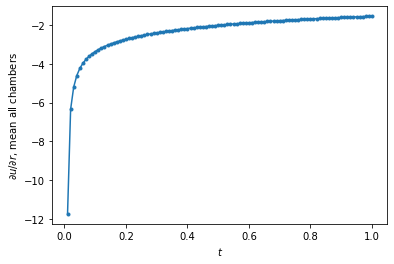

In [143]:
''' Compare normal gradient value at boundary '''

# Extract gradients at inner circle boundary
dudr_hist = u_hist[:,:n_circ_in_elts,0]
# dudr_numerical_steady = -u_s[:n_circ_in_elts].squeeze()

t_plot_range = (dt + dt*np.arange(0,N_t))
plt.plot(t_plot_range, -dudr_hist.mean(axis=1), '.-')
plt.xlabel("$t$")
plt.ylabel("$\partial u/\partial r$, mean all chambers")